# Model Spikey observed by Kepler with UltraNest

In this notebook we use the Bayesian inference package `UltraNest`, using nested sampling, to model the Kepler observation of Spikey, reduced by Smith+2016. 

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# Built-in
import os
import sys
import json
import copy
import datetime

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as c
from pathlib import Path
from functools import partial
# UltraNest
import ultranest
import ultranest.stepsampler
from ultranest import ReactiveNestedSampler
from ultranest.plot import cornerplot

# Internal methods
sys.path.append('../src')
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

In [9]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'

---
## 1. Modelling DM light curve ala Hu+2020
---

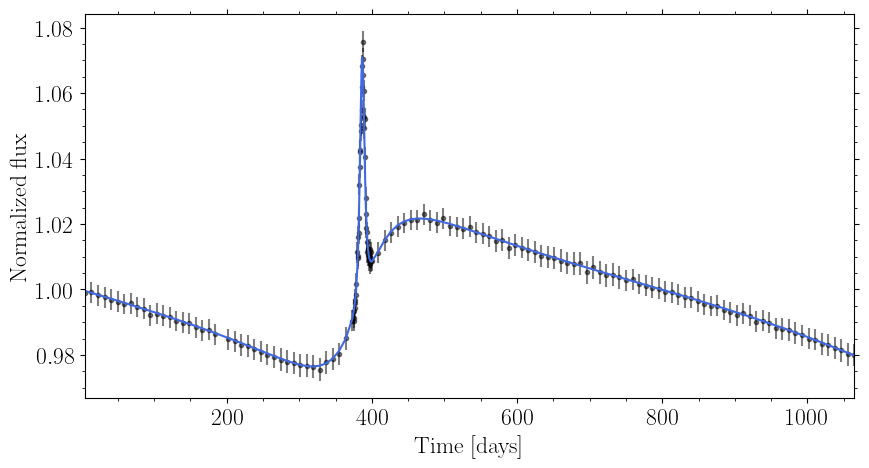

In [10]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_csv(ddir / 'data_spikey_DM_kepler_hu2020.csv')
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0 
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Normalize light curve to model
df.flux = df.flux * dm.flux.median() / df.flux.median()

# Plot light curve
pt.plot_lc(df, dm);

---
### 1.1. Parameterization with `logM1` and `logM2`

In [11]:
values = [params.t0, params.P, params.i, params.e, params.w, params.logM1, params.logM2, params.L, params.alpha]

#### *1.1.1. Uniform priors*

In [126]:
filename = 'spikey_kepler_DM_hu2020_logM1logM2_ultranest_uniform_test0'
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.05]
priors.P     = [params.P*0.95, params.P*1.05]
priors.i     = [0, 90]                          # Changed
priors.e     = [params.e*0.9, params.e*1.1]
priors.w     = [params.w*0.9, params.w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.9, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-4e+03  807.63 [-3808.5681..-3808.5671]*| it/evals=15920/881537 eff=1.8068% N=400 0 
# [ultranest] Likelihood function evaluations: 882001
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -3844 +- 0.182
# [ultranest] Effective samples strategy satisfied (ESS = 3355.1, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.13 to 0.58, need <0.5)
# [ultranest]   logZ error budget: single: 0.28 bs:0.18 tail:0.01 total:0.18 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:01:49.450776 [h:mm:ss]

# logZ = -3843.577 +- 0.318
#   single instance: logZ = -3843.577 +- 0.279
#   bootstrapped   : logZ = -3843.588 +- 0.318
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.88% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.06395│ ▁▁▁▁▁▁▁▁▁▂▁▂▃▄▄▅▅▇▇▇▇▆▆▅▄▃▃▂▂▁▁▁▁▁▁▁▁ │1.06612    1.06509 +- 0.00027
#     P                   : 1.113 │ ▁▁▁▁▁▁▁▁▁▃▃▄▅▆▆▇▇▇▇▆▆▄▄▄▂▂▁▁▁▁▁▁▁▁▁  ▁│1.201     1.154 +- 0.010
#     i                   : 81.19 │ ▁   ▁▁▁▁▁▁▁▁▁▁▂▃▃▄▅▆▇▇▇▆▆▅▄▃▂▂▁▁▁▁  ▁ │83.80     82.70 +- 0.28
#     e                   : 0.472 │▁▁▁▁▁▂▂▃▃▄▅▅▆▇▇▇▇▇▇▇▆▅▄▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁ │0.542     0.501 +- 0.010
#     w                   : 92.632│ ▁ ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▅▆▇│93.093    93.045 +- 0.049
#     logM1               : 7.095 │ ▁   ▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▅▅▃▃▂▂▁▁▁▁▁▁▁  ▁ │7.476     7.285 +- 0.041
#     logM2               : 6.31  │ ▁ ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▅▆▆▇▇▇▆▅▄▃▂▁▁▁▁ ▁ │7.39      6.99 +- 0.11
#     L                   : 0.9390│ ▁  ▁ ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▂▂▃▄▄▅▅▆▇▇│1.0000    0.9909 +- 0.0082
#     alpha               : 1.881 │▁▁▁▂▂▃▄▄▅▅▆▆▆▇▇▇▇▆▆▅▄▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁ │2.164     1.983 +- 0.042

In [93]:
filename = 'spikey_kepler_DM_hu2020_logM1logM2_ultranest_uniform_test1'
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.1]
priors.P     = [params.P*0.9, params.P*1.3]
priors.i     = [0, 90]
priors.e     = [params.e*0.5, params.e*1.5]
priors.w     = [params.w*0.5, params.w*1.8] # Changed
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.5, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-3e+03  345.19 [-3345.7911..-3345.7905]*| it/evals=17000/2617955 eff=0.6495% N=400 00    
# [ultranest] Likelihood function evaluations: 2617999
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -3384 +- 0.2149
# [ultranest] Effective samples strategy satisfied (ESS = 3169.6, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.06 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.17 to 0.52, need <0.5)
# [ultranest]   logZ error budget: single: 0.29 bs:0.21 tail:0.01 total:0.22 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:05:24.451312 [h:mm:ss]

# logZ = -3383.510 +- 0.404
#   single instance: logZ = -3383.510 +- 0.292
#   bootstrapped   : logZ = -3383.574 +- 0.404
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.94 (should be >1), far enough fraction: 49.51% : very fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.0913│ ▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▆▆▅▅▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁ │1.1106    1.0999 +- 0.0023
#     P                   : 1.178 │ ▁▁▁▁▁▁▁▁▁▂▃▄▅▆▆▇▇▇▆▇▆▄▃▃▂▁▁▁▁▁▁▁▁  ▁▁ │1.369     1.266 +- 0.021
#     i                   : 78.19 │ ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▇▇▇▇▇▇▆▅▄▃▂▂▁▁▁▁▁▁▁▁ │82.20     80.36 +- 0.46
#     e                   : 0.6124│ ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▇▇▇▇▇▅▅▃▃▂▂▁▁▁▁▁▁▁▁ │0.6906    0.6546 +- 0.0089
#     w                   : 121.69│ ▁ ▁▁▁▁▁▁▁▁▂▂▂▃▅▅▆▆▇▇▇▆▆▅▃▃▂▁▁▁▁▁▁▁▁ ▁ │130.65    126.29 +- 0.97
#     logM1               : 7.396 │ ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▅▇▇▇▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁ │7.819     7.608 +- 0.049
#     logM2               : 7.515 │ ▁▁▁▁▁▁▁▁▁▁▂▃▃▅▅▇▆▇▇▇▆▆▅▄▄▂▂▁▁▁▁▁▁▁ ▁▁ │8.085     7.798 +- 0.067
#     L                   : 0.842 │ ▁  ▁▁▁▁▁▁▁▂▂▂▃▅▅▆▇▇▇▆▆▅▅▄▃▃▂▂▁▁▁▁▁▁▁▁ │0.969     0.909 +- 0.015
#     alpha               : 1.108 │ ▁   ▁▁▁▁▁▁▁▁▁▁▂▂▄▅▆▆▇▇▇▇▆▅▄▃▂▂▁▁▁▁▁ ▁ │1.935     1.590 +- 0.084

In [12]:
filename = 'spikey_kepler_DM_hu2020_logM1logM2_ultranest_uniform'
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [0.1, 3.]
priors.P     = [0.1, 3.]
priors.i     = [0.1, 89]
priors.e     = [0.1, 0.9]
priors.w     = [0.1, 359]
priors.logM1 = [5., 11.]
priors.logM2 = [5., 11.]
priors.L     = [0., 1.]
priors.alpha = [0.1, 4.]
priors.vz    = params.vz
# [ultranest] Explored until L=-3e+03  755.44 [-2756.3296..-2756.3288]*| it/evals=24440/52893820 eff=0.0462% N=400  
# [ultranest] Likelihood function evaluations: 52894164
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -2813 +- 0.2164
# [ultranest] Effective samples strategy satisfied (ESS = 3280.0, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.22, need <0.5)
# [ultranest]   logZ error budget: single: 0.36 bs:0.22 tail:0.01 total:0.22 required:<0.50
# [ultranest] done iterating.
# Execution time: 1:32:01.169592 [h:mm:ss]

# logZ = -2812.608 +- 0.395
#   single instance: logZ = -2812.608 +- 0.362
#   bootstrapped   : logZ = -2812.644 +- 0.395
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.80 (should be >1), far enough fraction: 35.45% : very fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.05826│ ▁      ▁▁▁▁▁▁▁▁▂▃▄▅▇▇▇▇▇▆▆▄▃▂▁▁▁▁▁▁▁▁ │1.05988    1.05922 +- 0.00015
#     P                   : 0.988 │ ▁▁▁▂▄▆▇▇▇▇▆▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁ ▁▁▁▁▁  ▁▁ │1.176     1.039 +- 0.019
#     i                   : 6.094 │ ▁▁▁▁▁▁▁▁▁▁▁▂▃▃▄▄▅▆▆▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁ ▁▁ │6.839     6.473 +- 0.082
#     e                   : 0.8432│ ▁▁▁▁▁▁▂▂▃▄▄▆▇▇▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁ ▁ │0.8654    0.8524 +- 0.0025
#     w                   : 258.9 │ ▁▁▁▁▁▁▁▁▁▁▃▃▃▅▅▆▇▇▇▆▆▆▅▄▃▃▂▂▁▁▁▁▁▁▁ ▁ │267.1     262.9 +- 1.0
#     logM1               : 9.641 │ ▁▁▁▁▁▁▁▁▁▂▂▃▄▅▅▆▇▇▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁ │9.770     9.704 +- 0.015
#     logM2               : 10.446│ ▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▅▆▆▇▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁ │10.532    10.491 +- 0.010
#     L                   : 0.98557│ ▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▆▇▆▆▆▆▅▄▃▃▂▂▁▁▁▁▁▁▁ │0.99034    0.98821 +- 0.00056
#     alpha               : 3.9783│ ▁  ▁▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▅▆▇│4.0000    3.9978 +- 0.0021

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-3e+03  755.50 [-2756.3090..-2756.3089]*| it/evals=24407/108824918 eff=0.0224% N=400 
[ultranest] Likelihood function evaluations: 108824918
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -2813 +- 0.2867
[ultranest] Effective samples strategy satisfied (ESS = 3296.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.24 to 0.75, need <0.5)
[ultranest]   logZ error budget: single: 0.36 bs:0.29 tail:0.01 total:0.29 required:<0.50
[ultranest] done iterating.
Execution time: 3:41:19.030526 [h:mm:ss]

logZ = -2812.507 +- 0.752
  single instance: logZ = -2812.507 +- 0.362
  bootstrapped   : logZ = -2812.537 +- 0.752
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump 

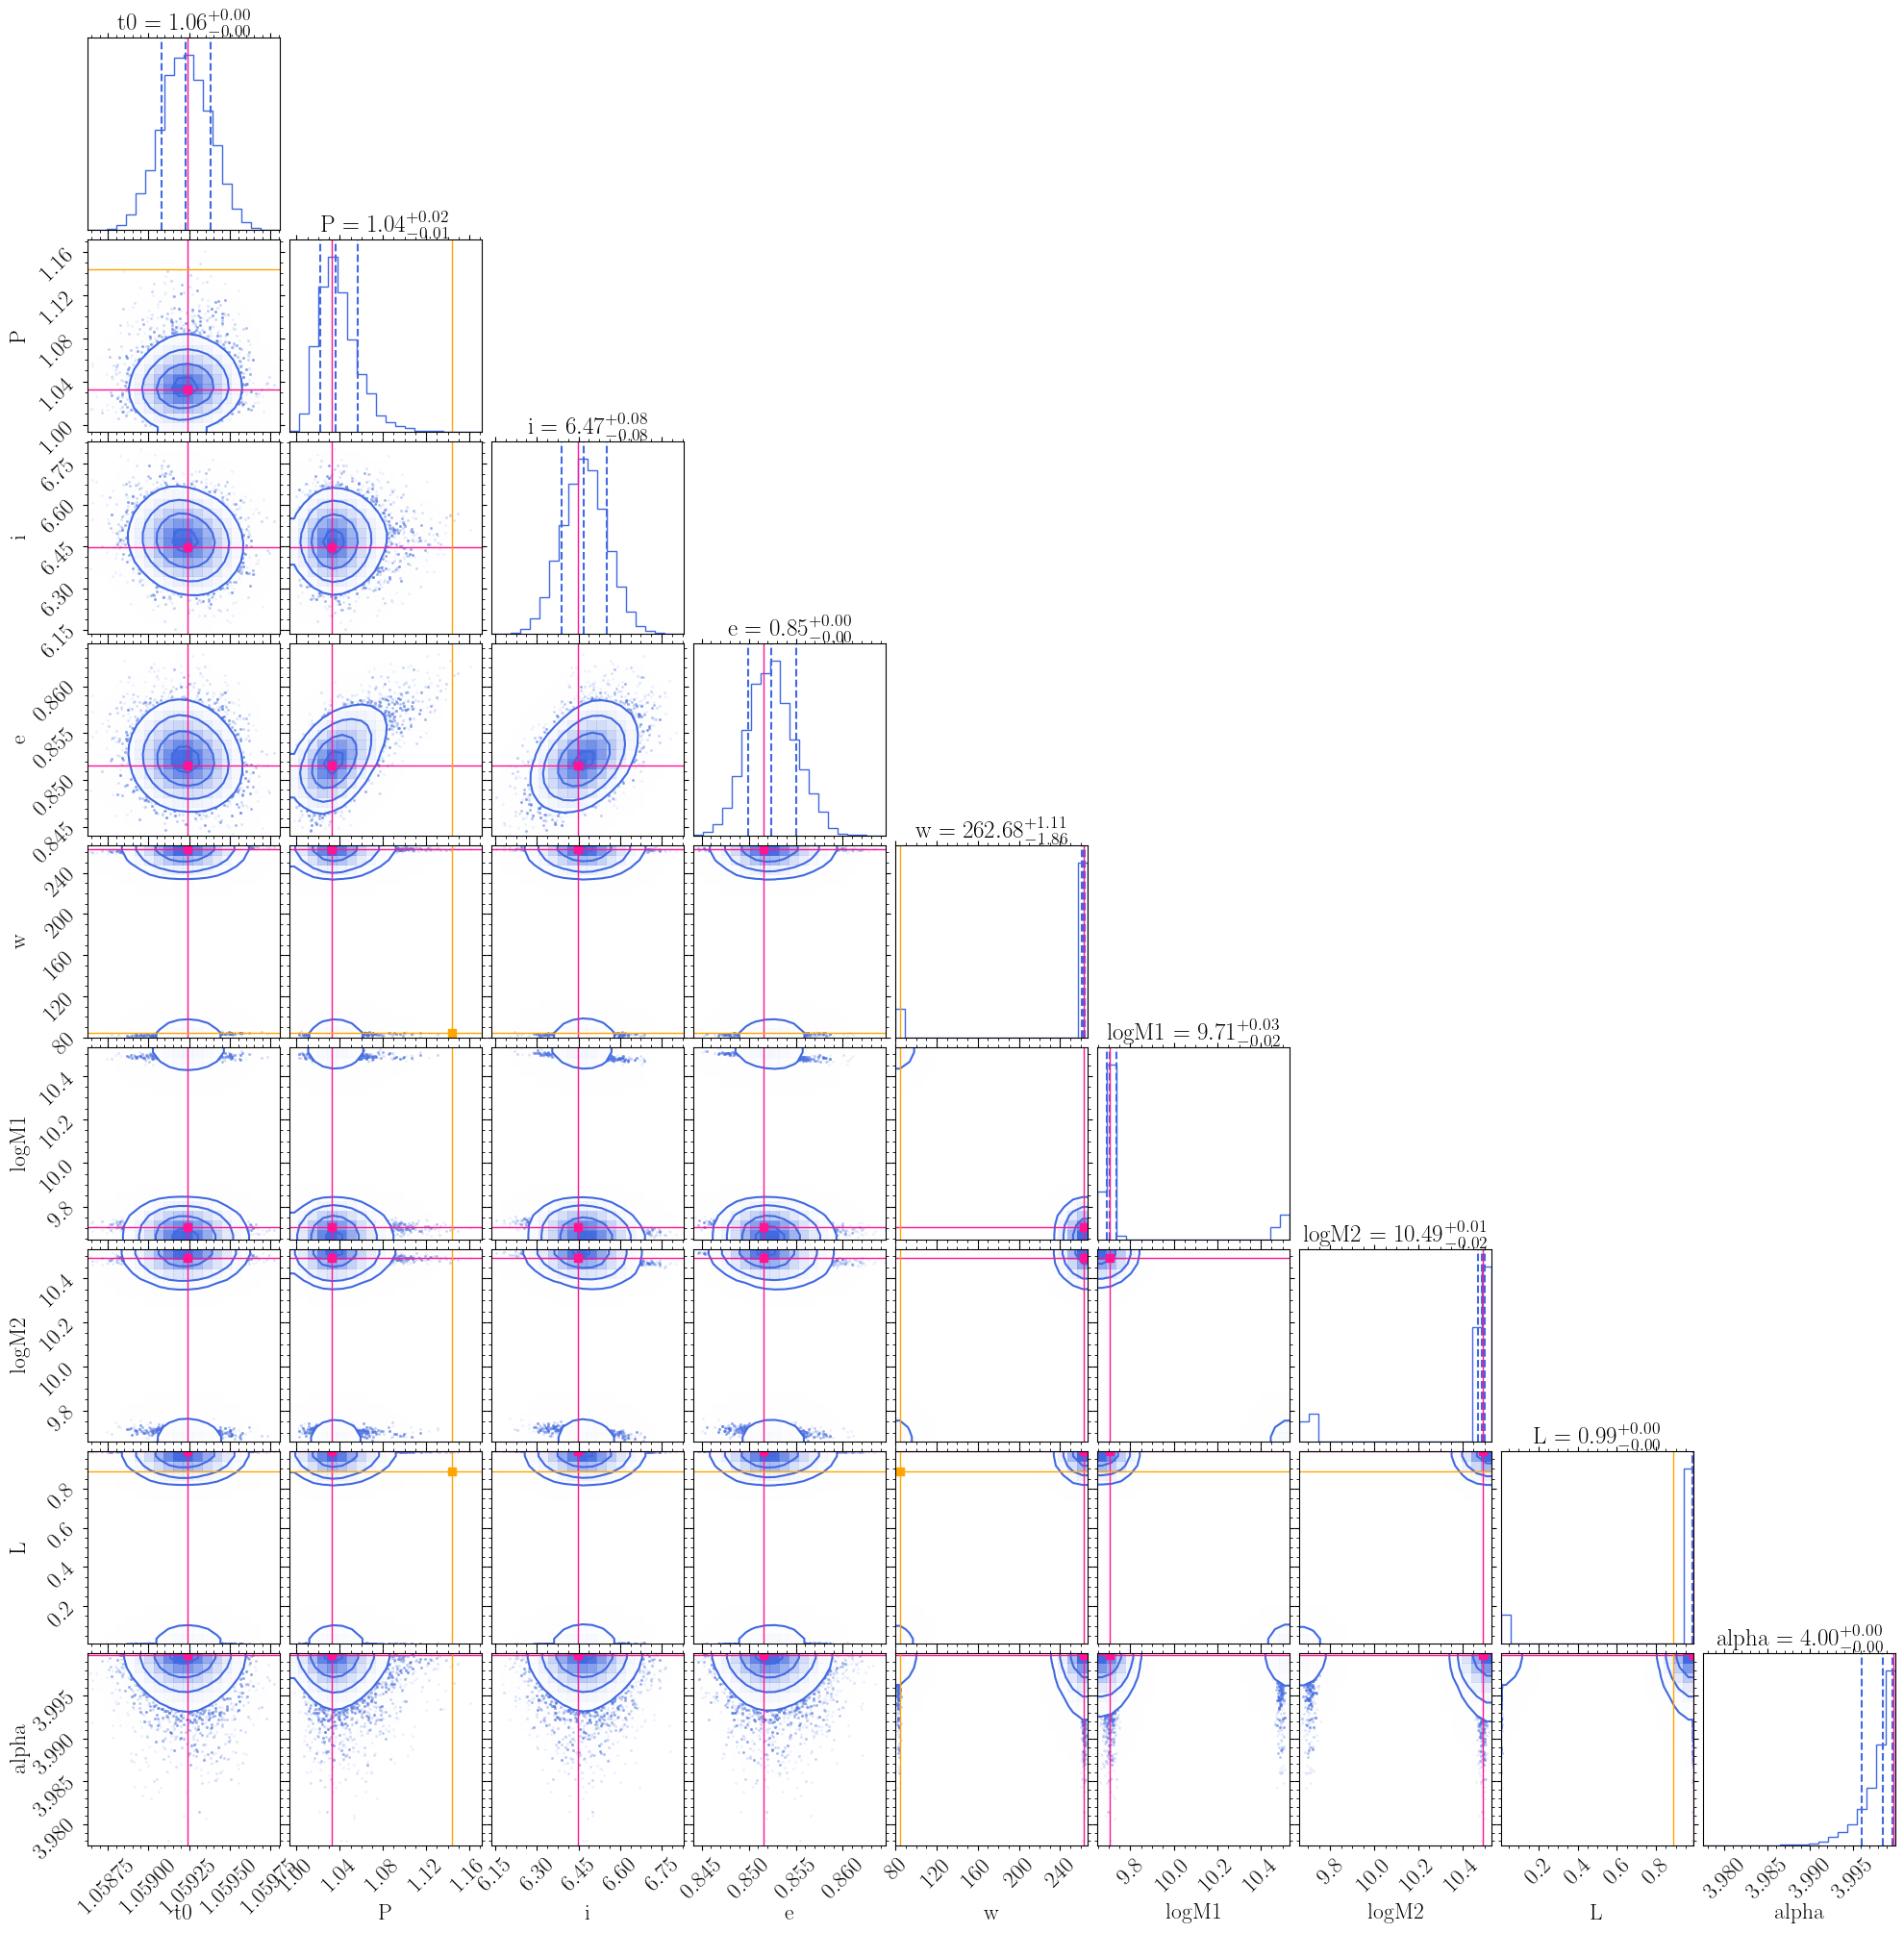

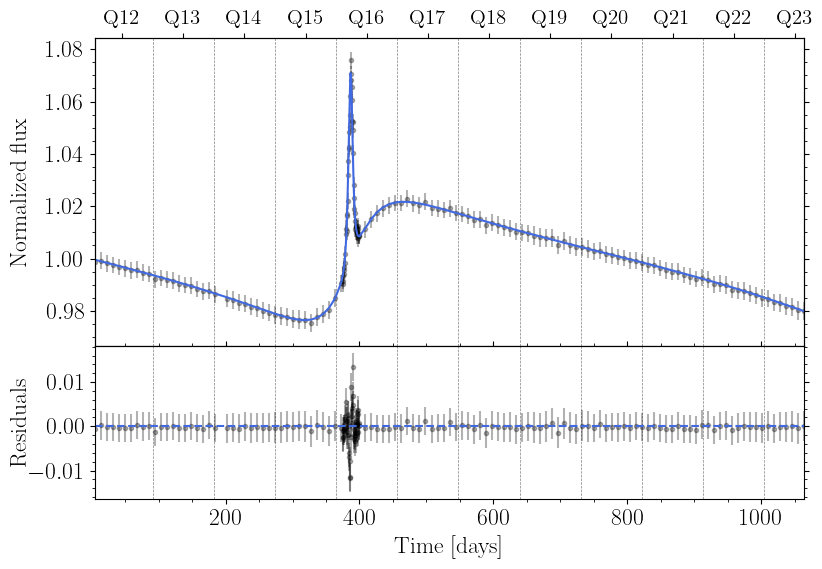

In [13]:
%%time
# Run UltraNest analysis
result, sampler = bs.run_ultranest(df, params, priors, rdir/filename)
# Show corner plot
fig = pt.plot_corner(result, bestfit='maximum', values_input=values);
fig.savefig(rdir / filename / 'plots' / f'{filename}_corner.png', bbox_inches='tight', dpi=200)
# Create best-fit model and plot along with data
params_model = copy.deepcopy(params)
params_model.sigma = 0
dm = bs.bestfit_model(time, params_model, result)
fig, ax = pt.plot_result(df, dm, Q0=12, alpha=0.3, figsize=(8.5, 6))
fig.savefig(rdir / filename / 'plots' / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200);

---
### 1.2. Paramterisation using `logM` and `q`

In [22]:
# Generate relativistic Spikey model
params = smbhb.model_params_q()
params.sigma = 0 
model = smbhb.model_q(params)
dm = model.light_curve(time, df=True)
values = [params.t0, params.P, params.i, params.e, params.w, params.logM, params.q, params.L, params.alpha]

#### *1.1.1. Uniform priors*

In [20]:
filename = 'spikey_kepler_DM_hu2020_logMq_ultranest_uniform_test0'
priors = bs.model_priors_q()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.05]
priors.P     = [params.P*0.95, params.P*1.05]
priors.i     = [0, 90]
priors.e     = [params.e*0.9, params.e*1.1]
priors.w     = [params.w*0.9, params.w*1.1]
priors.logM  = [5, 11]
priors.q     = [0, 1]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.9, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-4e+03  782.52 [-3783.3961..-3783.3957]*| it/evals=15225/668871 eff=2.2776% N=400    
# [ultranest] Likelihood function evaluations: 668890
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -3817 +- 0.1918
# [ultranest] Effective samples strategy satisfied (ESS = 3233.2, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.19, need <0.5)
# [ultranest]   logZ error budget: single: 0.27 bs:0.19 tail:0.01 total:0.19 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:01:24.135220 [h:mm:ss]

# logZ = -3816.629 +- 0.488
#   single instance: logZ = -3816.629 +- 0.271
#   bootstrapped   : logZ = -3816.633 +- 0.488
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.94 (should be >1), far enough fraction: 50.92% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.06344│ ▁ ▁▁▁▁▁▁▁▁▂▂▄▄▅▆▆▇▇▇▆▆▅▄▃▃▂▁▁▁▁▁▁▁ ▁▁ │1.06568    1.06455 +- 0.00027
#     P                   : 1.1176│ ▁▁▁▁▁▁▁▁▁▂▂▄▅▅▆▆▇▇▇▇▅▅▄▄▃▂▁▁▁▁▁▁▁▁▁ ▁ │1.2012    1.1571 +- 0.0100
#     i                   : 81.54 │ ▁ ▁▁▁▁▁▁▁▂▂▂▄▄▅▆▆▇▇▇▇▇▅▅▃▃▂▁▁▁▁▁▁▁  ▁ │83.93     82.73 +- 0.28
#     e                   : 0.472 │▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▆▇▆▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁   ▁ │0.554     0.503 +- 0.011
#     w                   : 92.630│ ▁  ▁   ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▄▅▆▇│93.093    93.045 +- 0.048
#     logM                : 7.203 │ ▁ ▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▅▆▆▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁ │7.682     7.472 +- 0.056
#     q                   : 0.154 │ ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▄▅▅▆▇▇▆▆▆▄▃▃▂▁▁▁▁▁▁▁ ▁ │0.875     0.537 +- 0.087
#     L                   : 0.9406│ ▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▂▃▃▃▄▄▄▅▇▇▇▇│1.0000    0.9904 +- 0.0081
#     alpha               : 1.881 │▁▂▂▂▃▃▄▅▅▆▆▇▇▆▇▇▆▆▄▄▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁ ▁ │2.166     1.979 +- 0.042

In [134]:
filename = 'spikey_kepler_DM_hu2020_logMq_ultranest_uniform_test1'
priors = bs.model_priors_q()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.1]
priors.P     = [params.P*0.9, params.P*1.3]
priors.i     = [0, 90]
priors.e     = [params.e*0.5, params.e*1.5]
priors.w     = [params.w*0.5, params.w*2.5]
priors.logM  = [5, 11]
priors.q     = [0, 1]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.5, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-3e+03  365.72 [-3366.5589..-3366.5586]*| it/evals=16840/1621327 eff=1.0389% N=400  
# [ultranest] Likelihood function evaluations: 1621668
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -3404 +- 0.243
# [ultranest] Effective samples strategy satisfied (ESS = 3311.1, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.20 to 0.53, need <0.5)
# [ultranest]   logZ error budget: single: 0.29 bs:0.24 tail:0.01 total:0.24 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:02:51.740354 [h:mm:ss]

# logZ = -3403.857 +- 0.412
#   single instance: logZ = -3403.857 +- 0.289
#   bootstrapped   : logZ = -3403.891 +- 0.412
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.76% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.0987│ ▁▁▁▁▁▁▁▁▂▃▄▅▇▇▇▇▆▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁ ▁▁ │1.1211    1.1081 +- 0.0024
#     P                   : 1.197 │ ▁▁▁▁▁▁▁▁▁▁▂▃▄▅▆▆▆▇▅▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁  ▁ │1.386     1.284 +- 0.020
#     i                   : 80.37 │ ▁   ▁▁▁▁▁▁▁▁▂▂▃▄▅▇▇▇▇▇▆▆▄▄▂▂▁▁▁▁▁▁▁▁▁ │83.34     81.97 +- 0.30
#     e                   : 0.5888│ ▁▁▁▁▁▁▁▁▁▂▂▃▃▅▅▇▇▇▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁ │0.6530    0.6209 +- 0.0081
#     w                   : 121.8 │ ▁ ▁▁▁▁▁▁▁▁▂▂▃▅▄▆▆▇▇▇▇▅▅▄▃▃▂▁▁▁▁▁▁▁▁ ▁ │132.0     126.9 +- 1.2
#     logM                : 7.493 │ ▁   ▁ ▁▁▁▁▁▁▁▂▃▄▆▆▇▇▇▆▅▄▃▂▂▁▁▁▁▁  ▁▁▁ │7.882     7.697 +- 0.037
#     q                   : 0.857 │ ▁ ▁▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▇▇│1.000     0.985 +- 0.015
#     L                   : 0.796 │ ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▄▅▇▇▇▇▇▆▅▅▄▃▂▂▁▁▁▁▁▁▁▁▁ │0.933     0.866 +- 0.016
#     alpha               : 1.100 │ ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▇▆▄▃▂▁▁▁▁▁▁▁  ▁ │1.834     1.484 +- 0.083

In [23]:
filename = 'spikey_kepler_DM_hu2020_logMq_ultranest_uniform'
priors = bs.model_priors_q()
priors.z     = params.z
priors.t0    = [0.1, 3.]
priors.P     = [0.1, 3.]
priors.i     = [0.1, 89]
priors.e     = [0.1, 0.9]
priors.w     = [0.1, 359]
priors.logM  = [5., 11.]
priors.q     = [0., 1.]
priors.L     = [0., 1.]
priors.alpha = [0.1, 4.]
priors.vz    = params.vz
# [ultranest] Explored until L=-3e+03  755.31 [-2756.3894..-2756.3886]*| it/evals=24544/51271115 eff=0.0479% N=400 0   
# [ultranest] Likelihood function evaluations: 51271444
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -2813 +- 0.2802
# [ultranest] Effective samples strategy satisfied (ESS = 3260.7, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.22 to 0.63, need <0.5)
# [ultranest]   logZ error budget: single: 0.36 bs:0.28 tail:0.01 total:0.28 required:<0.50
# [ultranest] done iterating.
# Execution time: 1:50:45.467466 [h:mm:ss]

# logZ = -2812.910 +- 0.631
#   single instance: logZ = -2812.910 +- 0.363
#   bootstrapped   : logZ = -2812.924 +- 0.631
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.77 (should be >1), far enough fraction: 35.42% : very fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.05856│ ▁  ▁▁▁▁▁▁▁▁▂▃▃▄▅▆▇▆▇▇▆▇▆▅▃▃▂▁▁▁▁▁▁▁▁▁ │1.05982    1.05922 +- 0.00015
#     P                   : 0.990 │ ▁▁▁▃▅▇▇▇▇▆▅▄▃▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁  ▁ ▁ │1.182     1.038 +- 0.019
#     i                   : 6.177 │ ▁▁▁▁▁▁▁▂▂▃▄▅▅▇▇▇▇▇▇▇▆▅▃▂▂▂▁▁▁▁▁▁▁▁▁ ▁ │6.831     6.471 +- 0.079
#     e                   : 0.8416│ ▁ ▁▁▁▁▁▁▂▃▄▅▇▇▇▇▇▆▅▅▃▂▂▁▁▁▁▁▁▁▁ ▁ ▁ ▁ │0.8675    0.8523 +- 0.0026
#     w                   : 78.05 │ ▁  ▁▁▁▁▁▁▁▁▁▁▂▃▄▅▅▆▇▇▇▆▆▅▄▄▃▂▁▁▁▁▁▁▁▁ │86.69     82.87 +- 0.97
#     logM                : 10.508│ ▁ ▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▆▅▅▄▃▃▂▂▁▁▁▁▁▁▁ │10.596    10.557 +- 0.010
#     q                   : 0.1470│ ▁ ▁▁▁▁▁▁▁▂▂▂▃▄▆▆▆▇▇▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁ ▁ │0.1795    0.1636 +- 0.0040
#     L                   : 0.00971│ ▁▁▁▁▁▁▁▂▂▃▄▅▆▆▇▇▇▆▆▅▃▃▂▁▁▁▁▁▁▁▁▁ ▁ ▁▁ │0.01464    0.01178 +- 0.00055
#     alpha               : 3.9692│ ▁         ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▆▇│4.0000    3.9977 +- 0.0023


[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-3e+03  755.31 [-2756.3894..-2756.3886]*| it/evals=24544/51271115 eff=0.0479% N=400 0   
[ultranest] Likelihood function evaluations: 51271444
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -2813 +- 0.2802
[ultranest] Effective samples strategy satisfied (ESS = 3260.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.22 to 0.63, need <0.5)
[ultranest]   logZ error budget: single: 0.36 bs:0.28 tail:0.01 total:0.28 required:<0.50
[ultranest] done iterating.
Execution time: 1:50:45.467466 [h:mm:ss]

logZ = -2812.910 +- 0.631
  single instance: logZ = -2812.910 +- 0.363
  bootstrapped   : logZ = -2812.924 +- 0.631
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jum

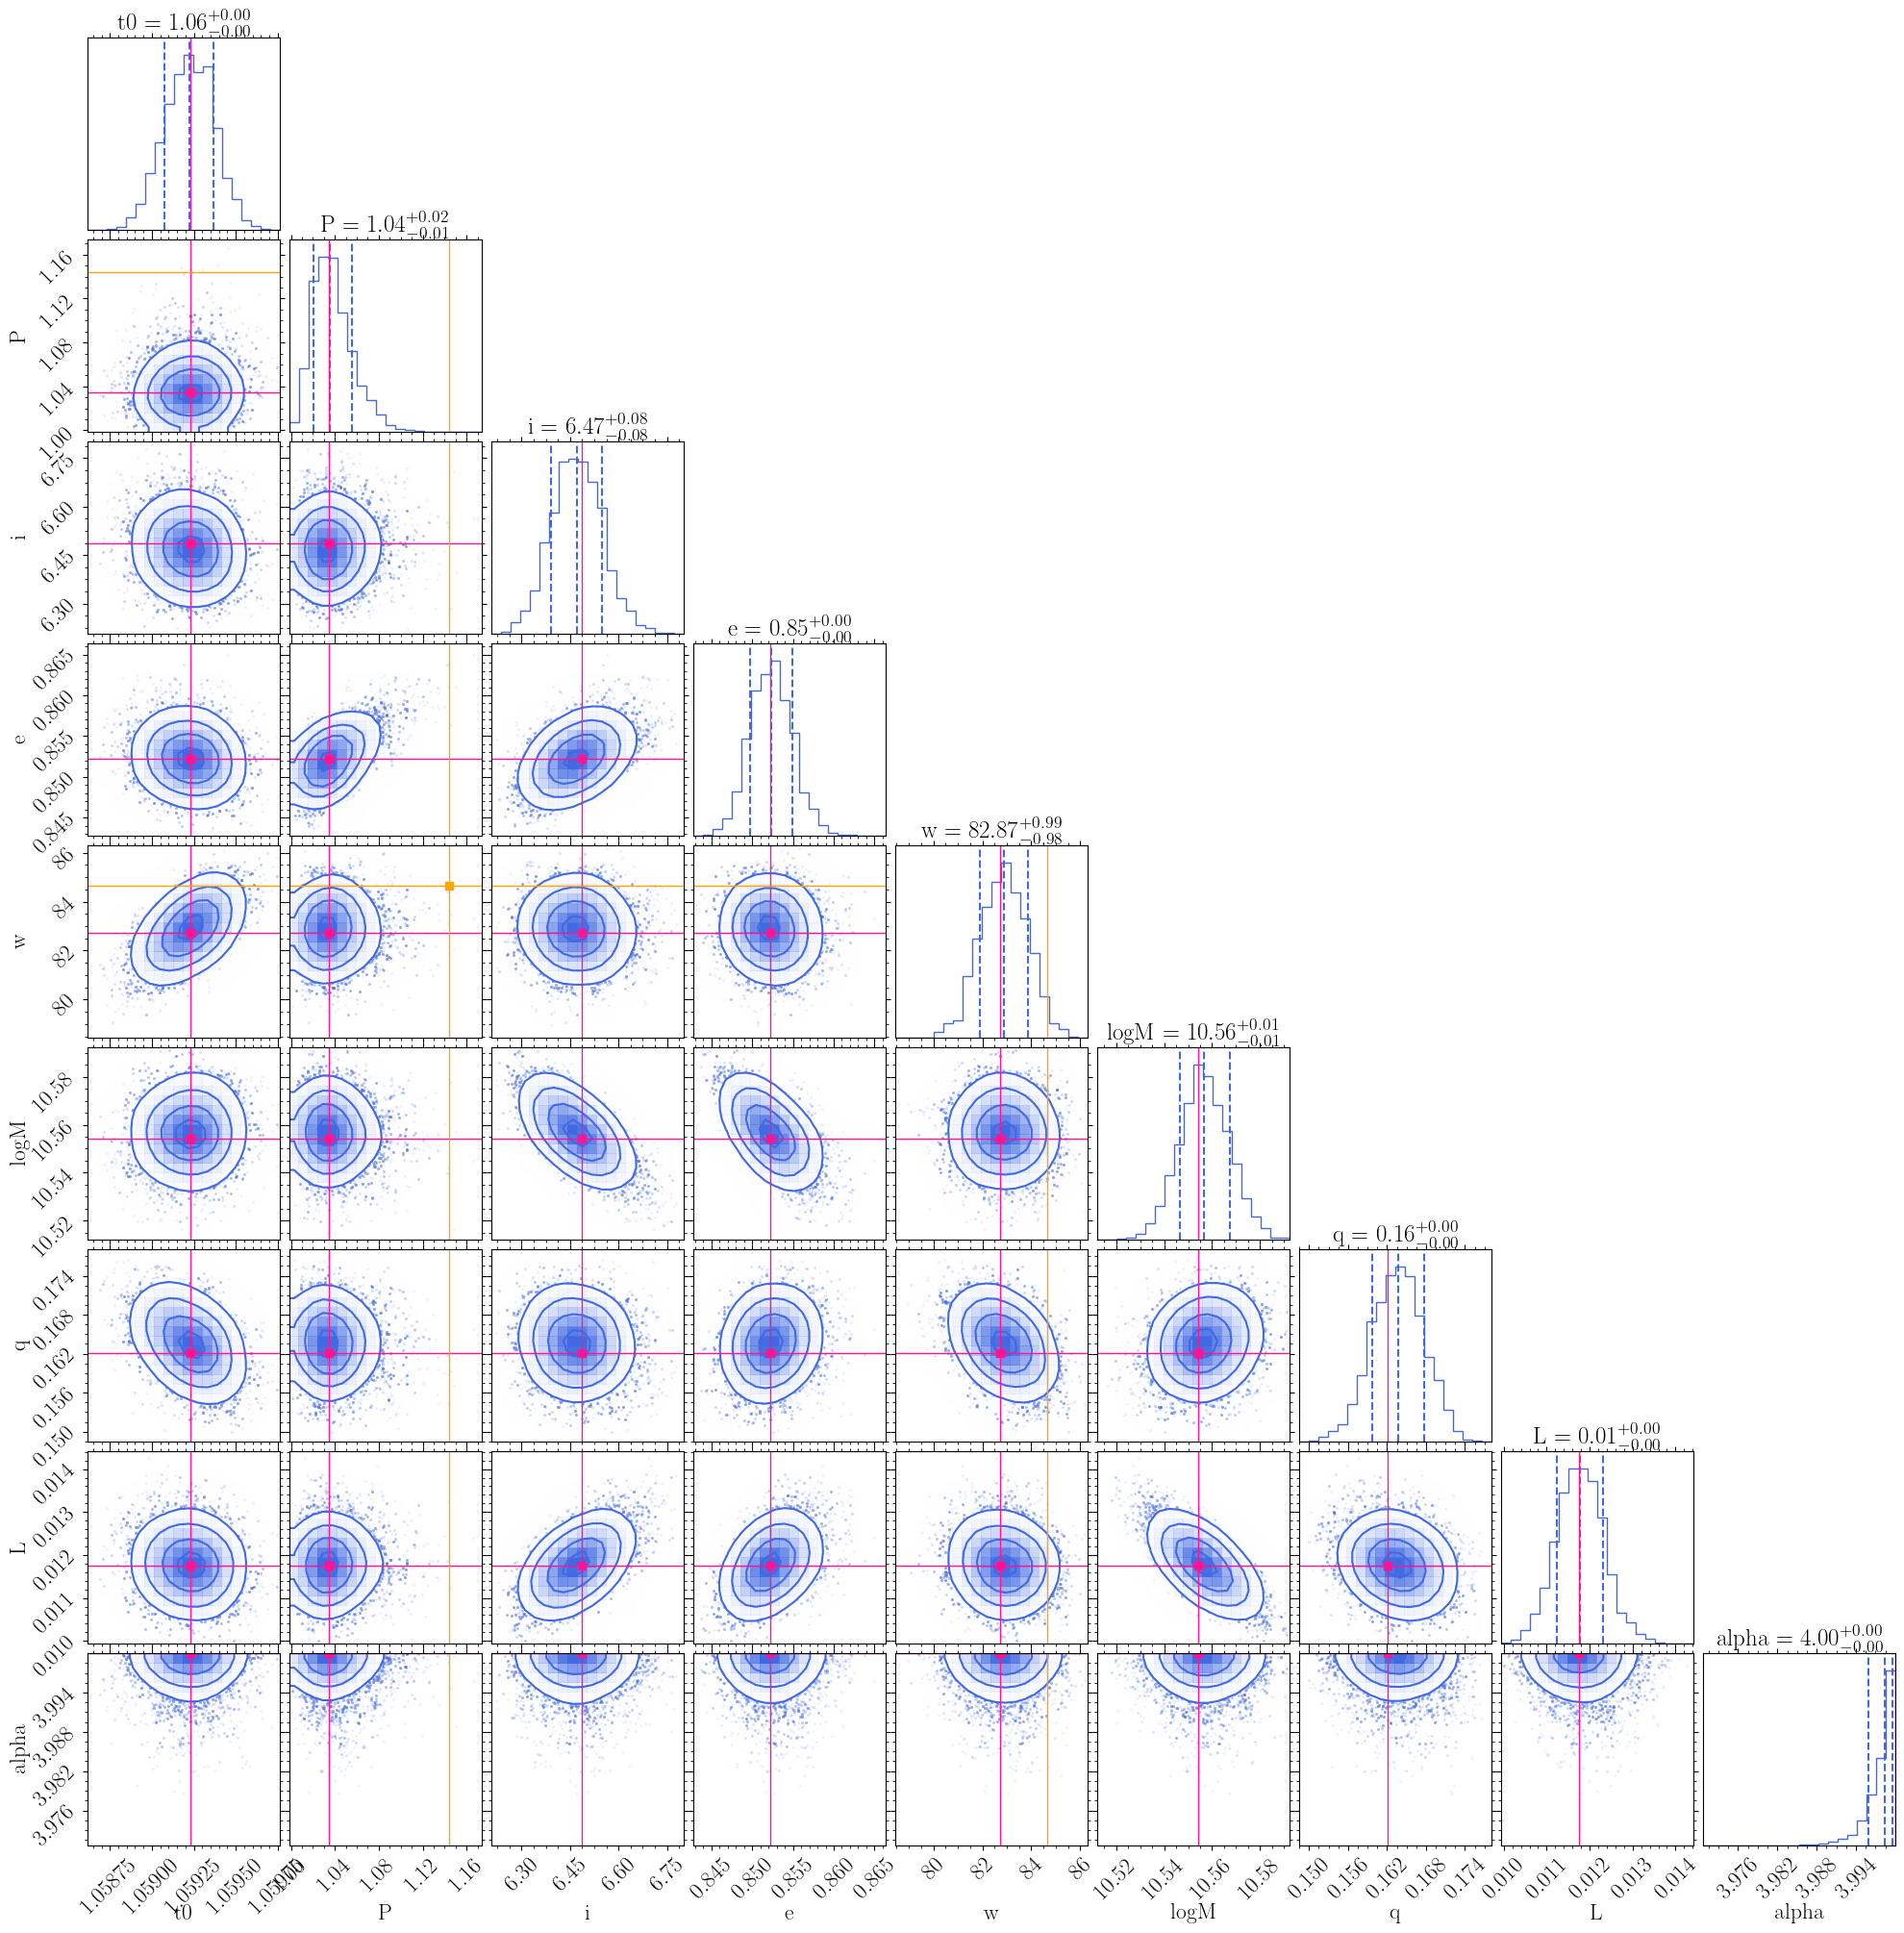

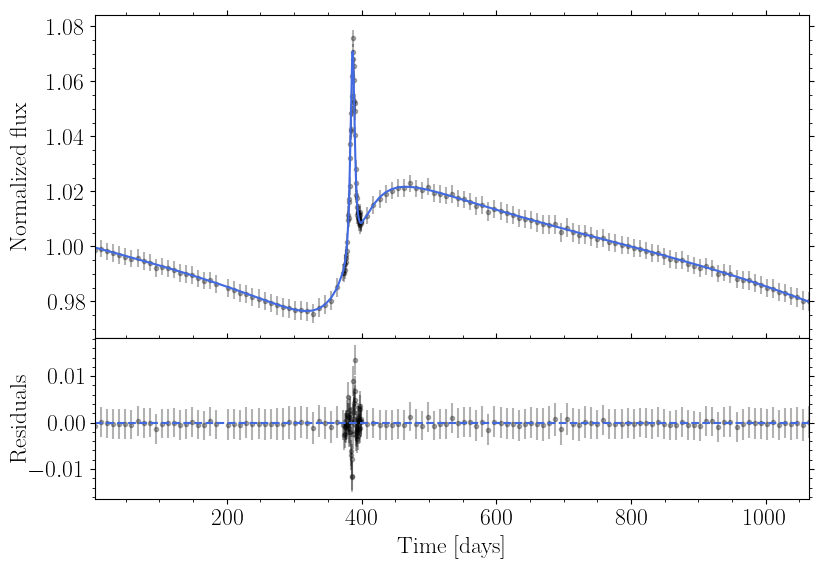

In [24]:
%%time
# Run UltraNest analysis
result, sampler = bs.run_ultranest_q(df, params, priors, rdir/filename)
# Show corner plot
fig = pt.plot_corner(result, bestfit='maximum', values_input=values);
fig.savefig(rdir / filename / 'plots' / f'{filename}_corner.png', bbox_inches='tight', dpi=200)
# Create best-fit model and plot along with data
params_model = copy.deepcopy(params)
params_model.sigma = 0
dm = bs.bestfit_model_q(time, params_model, result)
fig, ax = pt.plot_result(df, dm, Q0=12, alpha=0.3, figsize=(8.5, 6));
fig.savefig(rdir / filename / 'plots' / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200)

In [6]:
np.rad2deg(3 * np.pi /)

np.float64(270.0)